# 基于傅立叶相位差推断交通图边方向（多日拼接版）

- 将多天数据分段，计算真正的多段平均相干度
- 使用FFT计算相位差来估计时间延迟
- 相干度 = 频域相关系数，衡量各段相位差的一致性

## 1. 环境配置

In [1]:
import pandas as pd
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt
import os
import warnings
warnings.filterwarnings('ignore')

OUTPUT_DIR = "../output/edge_inference"
META_DIR = "../d03_meta_processed"
DATA_DIR = "/data/yuzhang_fei/PEMS/PEMSD3_2025"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("库加载完成！")

库加载完成！


## 2. 加载数据

In [2]:
# 加载交通流数据
print("加载交通流数据...")
flow_df = pd.read_csv(
    os.path.join(DATA_DIR, 'pems_5min_merged.csv'),
    dtype={'Station': str},
    parse_dates=['Timestamp']
)
print(f"交通流数据: {len(flow_df):,} 行")

# 加载 ML 传感器元数据
print("\n加载传感器元数据...")
meta_df = pd.read_csv(
    os.path.join(META_DIR, 'sensors_common_2025.csv'),
    dtype={'ID': str, 'Fwy': str}
)
ml_meta = meta_df[meta_df['Type'] == 'ML'].copy()
print(f"ML 传感器数: {len(ml_meta)}")

# 筛选 ML 传感器的流量数据
ml_ids = set(ml_meta['ID'])
flow_ml = flow_df[flow_df['Station'].isin(ml_ids)].copy()
print(f"ML 流量数据: {len(flow_ml):,} 行")

加载交通流数据...
交通流数据: 196,416,876 行

加载传感器元数据...
ML 传感器数: 854
ML 流量数据: 88,879,188 行


In [3]:
# 提取日期信息
flow_ml['Date'] = flow_ml['Timestamp'].dt.date
flow_ml['DayOfWeek'] = flow_ml['Timestamp'].dt.dayofweek  # 0=Mon
flow_ml['TimeSlot'] = flow_ml['Timestamp'].dt.hour * 12 + flow_ml['Timestamp'].dt.minute // 5

# 查看可用日期
available_dates = sorted(flow_ml['Date'].unique())
print(f"可用日期数: {len(available_dates)}")
print(f"日期范围: {available_dates[0]} ~ {available_dates[-1]}")

可用日期数: 363
日期范围: 2025-01-01 ~ 2025-12-31


## 3. 选择用于分析的日期

In [4]:
# 选择连续的多天（建议 7-14 天工作日）
selected_dates = [
    pd.Timestamp('2025-01-06').date(),  # Mon
    pd.Timestamp('2025-01-07').date(),  # Tue
    pd.Timestamp('2025-01-08').date(),  # Wed
    pd.Timestamp('2025-01-09').date(),  # Thu
    pd.Timestamp('2025-01-10').date(),  # Fri
    pd.Timestamp('2025-01-11').date(),  # Mon
    pd.Timestamp('2025-01-12').date(),  # Tue
]

print(f"选择的分析日期 ({len(selected_dates)} 天):")
for d in selected_dates:
    print(f"  {d} ({d.strftime('%A')})")
print(f"\n拼接后序列长度: {len(selected_dates) * 288} 点")

选择的分析日期 (7 天):
  2025-01-06 (Monday)
  2025-01-07 (Tuesday)
  2025-01-08 (Wednesday)
  2025-01-09 (Thursday)
  2025-01-10 (Friday)
  2025-01-11 (Saturday)
  2025-01-12 (Sunday)

拼接后序列长度: 2016 点


## 4. 构建相邻传感器对

In [5]:
def build_adjacent_pairs(ml_meta):
    """
    构建相邻传感器对，确定理论方向
    """
    pairs = []
    
    for (fwy, direction), group in ml_meta.groupby(['Fwy', 'Dir']):
        sorted_group = group.sort_values('Abs_PM').reset_index(drop=True)
        
        for i in range(len(sorted_group) - 1):
            node1 = sorted_group.iloc[i]
            node2 = sorted_group.iloc[i + 1]
            
            distance = node2['Abs_PM'] - node1['Abs_PM']
            
            # 理论方向
            if direction in ['N', 'E']:
                source, target = node1['ID'], node2['ID']
            else:
                source, target = node2['ID'], node1['ID']
            
            pairs.append({
                'Node1': node1['ID'],
                'Node2': node2['ID'],
                'Fwy': fwy,
                'Dir': direction,
                'Distance': distance,
                'True_Source': source,
                'True_Target': target
            })
    
    return pd.DataFrame(pairs)


pairs_df = build_adjacent_pairs(ml_meta)
print(f"相邻传感器对数: {len(pairs_df)}")

相邻传感器对数: 814


## 5. 构建数据缓存

In [6]:
# 构建 pivot 表加速查询
print("构建数据索引...")
flow_pivot = flow_ml.pivot_table(
    index=['Station', 'Date'],
    columns='TimeSlot',
    values='Total_Flow',
    aggfunc='first'
)
print(f"Pivot 表形状: {flow_pivot.shape}")

构建数据索引...
Pivot 表形状: (309934, 288)


## 6. 傅立叶相位差计算（多段平均版）

### 相干度的正确计算

**单次 FFT 的问题**：
$$\gamma = \frac{|S_1 \cdot S_2^*|}{|S_1| \cdot |S_2|} = \frac{|S_1||S_2|}{|S_1||S_2|} = 1$$

单次 FFT 计算的相干度恒为 1，无法区分信号质量！

**多段平均相干度**：
$$\gamma^2(f) = \frac{|\langle S_1 \cdot S_2^* \rangle|^2}{\langle |S_1|^2 \rangle \cdot \langle |S_2|^2 \rangle}$$

其中 $\langle \cdot \rangle$ 表示对 K 段取平均。

**物理意义**：
- $\gamma = 1$：各段相位差一致（完美线性关系）
- $\gamma = 0$：各段相位差随机（不相关）

In [7]:
def get_multiday_series(flow_pivot, station, dates):
    """
    获取多天拼接的时间序列
    """
    series_list = []
    
    for date in dates:
        key = (station, date)
        try:
            if key in flow_pivot.index:
                day_series = flow_pivot.loc[key].values
                series_list.append(day_series)
            else:
                series_list.append(np.full(288, np.nan))
        except:
            series_list.append(np.full(288, np.nan))
    
    return np.concatenate(series_list)

In [8]:
def compute_lag_fft_multiday(series1, series2, n_days, target_periods_days=[1.0, 0.5, 1/3]):
    """
    使用多段平均计算 FFT 相位差和真正的相干度
    
    参数:
    - series1, series2: 多日拼接序列（288 × n_days 点）
    - n_days: 天数
    - target_periods_days: 目标周期（以天为单位）
    
    返回:
    - lag: 时间延迟（步数），正值表示 series1 领先
    - coherence: 真正的多段平均相干度
    
    相干度计算:
    - 将数据分成 K 段（每段 1 天 = 288 点）
    - 对每段分别做 FFT
    - γ = |⟨S1·S2*⟩| / sqrt(⟨|S1|²⟩ · ⟨|S2|²⟩)
    """
    if series1 is None or series2 is None:
        return np.nan, np.nan
    
    seg_len = 288  # 每段长度（1天）
    n_segs = len(series1) // seg_len
    
    if n_segs < 2:
        return np.nan, np.nan
    
    # 收集有效的段
    valid_segs_1 = []
    valid_segs_2 = []
    
    for k in range(n_segs):
        start = k * seg_len
        end = start + seg_len
        seg1 = series1[start:end]
        seg2 = series2[start:end]
        
        # 检查该段是否有效（NaN 比例 < 20%）
        nan_ratio = (np.isnan(seg1).sum() + np.isnan(seg2).sum()) / (2 * seg_len)
        if nan_ratio < 0.2:
            # 填充少量 NaN（线性插值）
            seg1 = pd.Series(seg1).interpolate().fillna(method='bfill').fillna(method='ffill').values
            seg2 = pd.Series(seg2).interpolate().fillna(method='bfill').fillna(method='ffill').values
            valid_segs_1.append(seg1)
            valid_segs_2.append(seg2)
    
    K = len(valid_segs_1)
    if K < 2:
        return np.nan, np.nan
    
    # 对每段做 FFT
    ffts_1 = []
    ffts_2 = []
    
    for k in range(K):
        seg1 = valid_segs_1[k] - np.mean(valid_segs_1[k])  # 去均值
        seg2 = valid_segs_2[k] - np.mean(valid_segs_2[k])
        
        if np.std(seg1) < 1e-6 or np.std(seg2) < 1e-6:
            continue
            
        ffts_1.append(np.fft.fft(seg1))
        ffts_2.append(np.fft.fft(seg2))
    
    K = len(ffts_1)
    if K < 2:
        return np.nan, np.nan
    
    freqs = np.fft.fftfreq(seg_len)
    
    # 对每个目标周期计算相干度和相位差
    phase_diffs = []
    coherences = []
    weights = []
    
    for period_days in target_periods_days:
        period_samples = period_days * 288
        
        if period_samples > seg_len:
            continue
        
        target_freq = 1.0 / period_samples
        freq_idx = np.argmin(np.abs(freqs[:seg_len//2] - target_freq))
        
        if freq_idx == 0:
            continue
        
        # 收集各段在该频率的 FFT 值
        S1_list = [ffts_1[k][freq_idx] for k in range(K)]
        S2_list = [ffts_2[k][freq_idx] for k in range(K)]
        
        # ===== 多段平均相干度计算 =====
        # 交叉功率谱平均: ⟨S1·S2*⟩
        cross_avg = np.mean([S1_list[k] * np.conj(S2_list[k]) for k in range(K)])
        
        # 自功率谱平均: ⟨|S1|²⟩, ⟨|S2|²⟩
        power1_avg = np.mean([np.abs(S1_list[k])**2 for k in range(K)])
        power2_avg = np.mean([np.abs(S2_list[k])**2 for k in range(K)])
        
        denom = power1_avg * power2_avg
        if denom < 1e-10:
            continue
        
        # 相干度: γ = |⟨S1·S2*⟩| / sqrt(⟨|S1|²⟩·⟨|S2|²⟩)
        coh = np.abs(cross_avg) / np.sqrt(denom)
        
        # 相位差: 从平均交叉功率谱提取
        phase_diff = np.angle(cross_avg)
        
        # 能量权重
        energy = np.abs(cross_avg)
        
        # 相干性阈值
        if coh > 0.5:
            phase_diffs.append(phase_diff)
            coherences.append(coh)
            weights.append(energy * coh)
    
    if len(phase_diffs) == 0:
        return np.nan, np.nan
    
    # 加权平均
    weights = np.array(weights)
    weights = weights / np.sum(weights)
    avg_phase_diff = np.sum(np.array(phase_diffs) * weights)
    avg_coherence = np.sum(np.array(coherences) * weights)
    
    # 相位差转时间延迟（使用日周期 288 点作为参考）
    lag = avg_phase_diff / (2 * np.pi) * 288
    
    # 限制在合理范围
    if lag > 144:
        lag -= 288
    elif lag < -144:
        lag += 288
    
    return lag, avg_coherence

## 7. 批量分析

In [9]:
def analyze_all_pairs_fft_multiday(flow_pivot, pairs_df, selected_dates):
    """
    使用多日数据进行 FFT 分析
    """
    n_pairs = len(pairs_df)
    n_days = len(selected_dates)
    
    print(f"使用 {n_days} 天数据，每天作为一段计算相干度")
    
    # 预提取所有多日拼接序列
    print("提取序列到缓存...")
    series_cache = {}
    all_stations = set(pairs_df['Node1'].tolist() + pairs_df['Node2'].tolist())
    
    for station in all_stations:
        series_cache[station] = get_multiday_series(flow_pivot, station, selected_dates)
    
    print(f"缓存序列数: {len(series_cache)}")
    
    # 批量计算
    print("计算 FFT 相位差...")
    results = []
    
    for i, row in pairs_df.iterrows():
        node1, node2 = row['Node1'], row['Node2']
        
        s1 = series_cache.get(node1)
        s2 = series_cache.get(node2)
        
        lag, coh = compute_lag_fft_multiday(s1, s2, n_days)
        
        # 方向判断
        if np.isnan(lag):
            pred_source = 'unknown'
        elif lag > 0.5:
            pred_source = node1
        elif lag < -0.5:
            pred_source = node2
        else:
            pred_source = 'uncertain'
        
        result = {
            'Node1': node1,
            'Node2': node2,
            'Fwy': row['Fwy'],
            'Dir': row['Dir'],
            'Distance': row['Distance'],
            'True_Source': row['True_Source'],
            'Pred_Source': pred_source,
            'Lag': lag,
            'Coherence': coh
        }
        results.append(result)
        
        if (i + 1) % 100 == 0:
            print(f"  {i + 1}/{n_pairs}")
    
    print("分析完成！")
    return pd.DataFrame(results)

In [10]:
# 配置
METRIC = 'Total_Flow'

print(f"配置:")
print(f"  使用指标: {METRIC}")
print(f"  分析天数: {len(selected_dates)}")
print(f"  传感器对数: {len(pairs_df)}")

# 运行分析
print(f"\n开始分析...")
results_df = analyze_all_pairs_fft_multiday(flow_pivot, pairs_df, selected_dates)

配置:
  使用指标: Total_Flow
  分析天数: 7
  传感器对数: 814

开始分析...
使用 7 天数据，每天作为一段计算相干度
提取序列到缓存...
缓存序列数: 850
计算 FFT 相位差...
  100/814
  200/814
  300/814
  400/814
  500/814
  600/814
  700/814
  800/814
分析完成！


## 8. 评估精度

In [11]:
# 判断正确性
results_df['Correct'] = results_df['Pred_Source'] == results_df['True_Source']

# 统计
total = len(results_df)
uncertain = (results_df['Pred_Source'] == 'uncertain').sum()
unknown = (results_df['Pred_Source'] == 'unknown').sum()
valid = results_df[~results_df['Pred_Source'].isin(['uncertain', 'unknown'])]
correct = results_df['Correct'].sum()

print("=" * 60)
print("FFT 相位差方法（多段平均相干度版）- 精度评估")
print("=" * 60)
print(f"分析天数: {len(selected_dates)}")
print(f"\n总传感器对数: {total}")
print(f"有效预测数: {len(valid)} ({len(valid)/total*100:.1f}%)")
print(f"不确定数: {uncertain} ({uncertain/total*100:.1f}%)")
print(f"无数据数: {unknown} ({unknown/total*100:.1f}%)")
print(f"\n正确预测数: {correct}")
print(f"整体精度: {correct/total*100:.1f}%")
if len(valid) > 0:
    print(f"有效预测精度: {valid['Correct'].sum()/len(valid)*100:.1f}%")

FFT 相位差方法（多段平均相干度版）- 精度评估
分析天数: 7

总传感器对数: 814
有效预测数: 568 (69.8%)
不确定数: 246 (30.2%)
无数据数: 0 (0.0%)

正确预测数: 305
整体精度: 37.5%
有效预测精度: 53.7%


In [12]:
# 按方向统计
print("\n按方向统计:")
dir_stats = results_df.groupby('Dir').agg({
    'Correct': ['sum', 'count', 'mean']
}).round(3)
dir_stats.columns = ['正确数', '总数', '精度']
display(dir_stats)


按方向统计:


,正确数,总数,精度
Dir,,,
E,79,229,0.345
N,76,178,0.427
S,71,185,0.384
W,79,222,0.356


In [13]:
# 按距离统计
print("\n按距离统计:")
results_df['Dist_Bin'] = pd.cut(
    results_df['Distance'],
    bins=[0, 0.5, 1, 2, 5, 100],
    labels=['<0.5mi', '0.5-1mi', '1-2mi', '2-5mi', '>5mi']
)
dist_stats = results_df.groupby('Dist_Bin').agg({
    'Correct': ['sum', 'count', 'mean']
}).round(3)
dist_stats.columns = ['正确数', '总数', '精度']
display(dist_stats)


按距离统计:


,正确数,总数,精度
Dist_Bin,,,
<0.5mi,102,310,0.329
0.5-1mi,75,220,0.341
1-2mi,43,112,0.384
2-5mi,42,78,0.538
>5mi,35,69,0.507


In [14]:
# 按相干性统计
print("\n按相干性统计:")
results_df['Coh_Bin'] = pd.cut(
    results_df['Coherence'],
    bins=[0, 0.6, 0.7, 0.8, 0.9, 1.0],
    labels=['0.5-0.6', '0.6-0.7', '0.7-0.8', '0.8-0.9', '0.9-1.0']
)
coh_stats = results_df.groupby('Coh_Bin').agg({
    'Correct': ['sum', 'count', 'mean']
}).round(3)
coh_stats.columns = ['正确数', '总数', '精度']
display(coh_stats)


按相干性统计:


,正确数,总数,精度
Coh_Bin,,,
0.5-0.6,0,0,NaN
0.6-0.7,0,1,0.000
0.7-0.8,2,8,0.250
0.8-0.9,13,24,0.542
0.9-1.0,290,775,0.374


## 9. 可视化

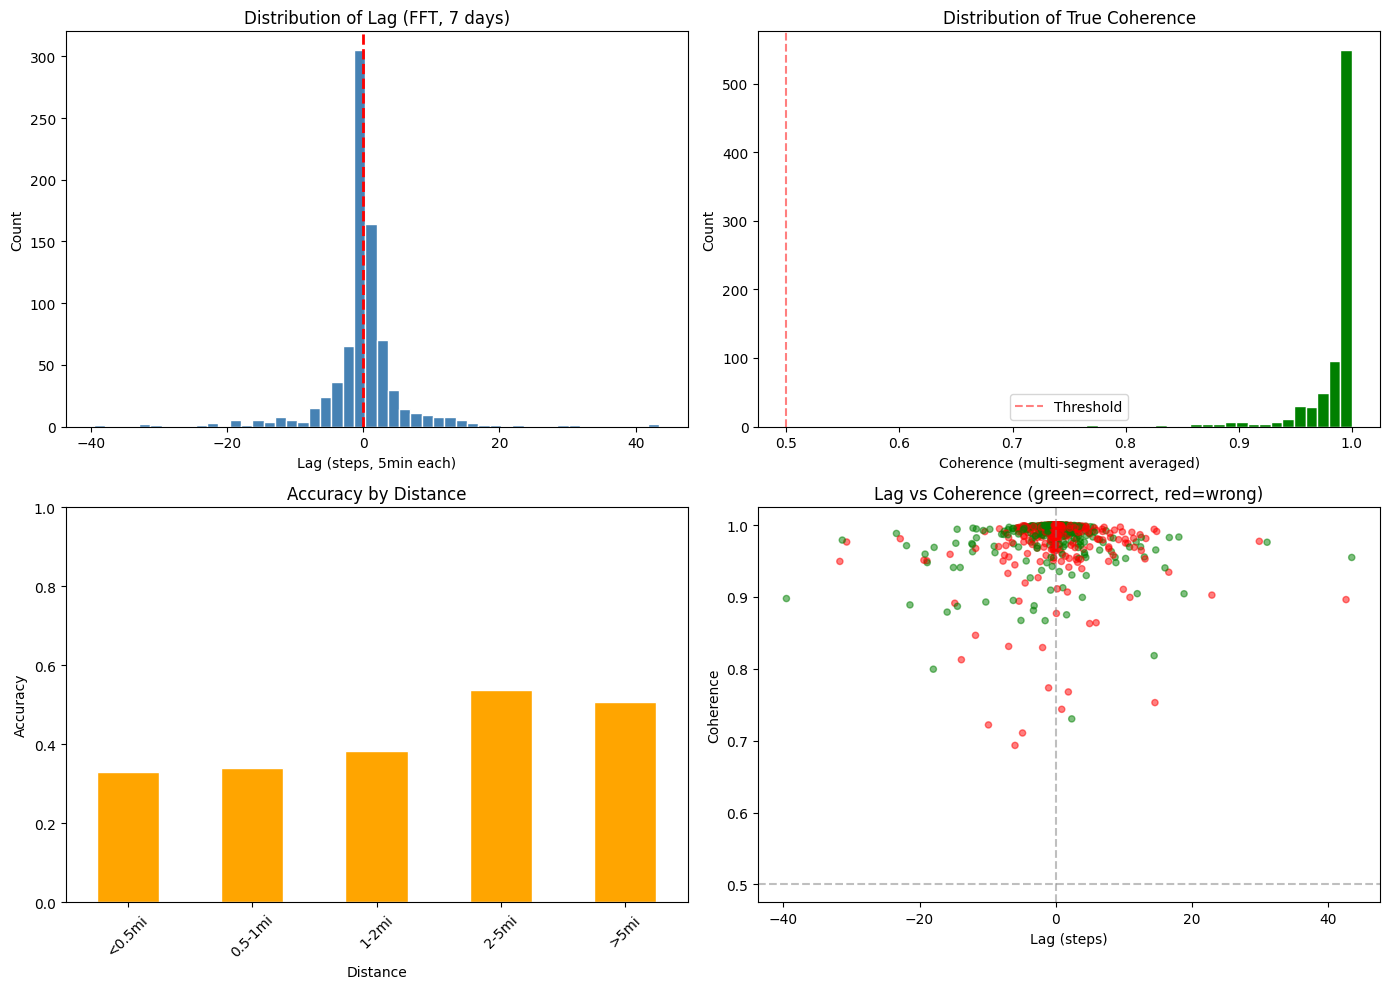

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. 滞后分布
valid_lags = results_df['Lag'].dropna()
axes[0, 0].hist(valid_lags, bins=50, color='steelblue', edgecolor='white')
axes[0, 0].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[0, 0].set_xlabel('Lag (steps, 5min each)')
axes[0, 0].set_ylabel('Count')
axes[0, 0].set_title(f'Distribution of Lag (FFT, {len(selected_dates)} days)')

# 2. 相干性分布（现在是真正的相干度，不再恒为1）
valid_coh = results_df['Coherence'].dropna()
axes[0, 1].hist(valid_coh, bins=30, color='green', edgecolor='white')
axes[0, 1].axvline(x=0.5, color='red', linestyle='--', alpha=0.5, label='Threshold')
axes[0, 1].set_xlabel('Coherence (multi-segment averaged)')
axes[0, 1].set_ylabel('Count')
axes[0, 1].set_title('Distribution of True Coherence')
axes[0, 1].legend()

# 3. 精度 vs 距离
dist_acc = results_df.groupby('Dist_Bin')['Correct'].mean()
dist_acc.plot(kind='bar', ax=axes[1, 0], color='orange', edgecolor='white')
axes[1, 0].set_xlabel('Distance')
axes[1, 0].set_ylabel('Accuracy')
axes[1, 0].set_title('Accuracy by Distance')
axes[1, 0].set_xticklabels(axes[1, 0].get_xticklabels(), rotation=45)
axes[1, 0].set_ylim(0, 1)

# 4. 滞后 vs 相干性
valid_df = results_df.dropna(subset=['Lag', 'Coherence'])
colors = ['green' if c else 'red' for c in valid_df['Correct']]
axes[1, 1].scatter(valid_df['Lag'], valid_df['Coherence'], c=colors, alpha=0.5, s=20)
axes[1, 1].axvline(x=0, color='gray', linestyle='--', alpha=0.5)
axes[1, 1].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
axes[1, 1].set_xlabel('Lag (steps)')
axes[1, 1].set_ylabel('Coherence')
axes[1, 1].set_title('Lag vs Coherence (green=correct, red=wrong)')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'direction_inference_fft_multiday.png'), dpi=150)
plt.show()

In [16]:
# 查看具体案例
print("\n预测正确的案例:")
display(results_df[results_df['Correct']][['Node1', 'Node2', 'Fwy', 'Dir', 'Distance', 
                                            'Lag', 'Coherence']].head(10))

print("\n预测错误的案例:")
wrong = results_df[~results_df['Correct'] & ~results_df['Pred_Source'].isin(['uncertain', 'unknown'])]
display(wrong[['Node1', 'Node2', 'Fwy', 'Dir', 'Distance', 'Lag', 
               'Coherence', 'True_Source', 'Pred_Source']].head(10))


预测正确的案例:


,Node1,Node2,Fwy,Dir,Distance,Lag,Coherence
2,316482,3415046,113,N,28.241,2.079891,0.989860
3,3415046,3415041,113,N,0.063,0.875411,0.998133
5,3085044,3034034,113,S,5.024,-6.192064,0.973944
6,3034034,3415047,113,S,28.255,-21.907360,0.971410
8,3010011,3413051,12,E,0.355,0.533709,0.935369
18,3413064,314521,160,N,36.372,13.009894,0.955684
22,3069012,3410017,162,W,18.012,-15.941682,0.878945
23,3022022,3090051,20,E,2.684,2.352474,0.730345
26,3085061,3423018,20,E,26.306,3.315248,0.973629
28,3422011,3422102,20,E,0.723,3.654336,0.997599



预测错误的案例:


,Node1,Node2,Fwy,Dir,Distance,Lag,Coherence,True_Source,Pred_Source
0,3034105,3085041,113,N,3.983,-3.070727,0.975654,3034105,3085041
1,3085041,316482,113,N,5.030,-3.302767,0.985443,3085041,316482
4,3034101,3085044,113,S,3.980,1.586534,0.985926,3085044,3034101
7,3415047,3415044,113,S,0.049,10.246963,0.975001,3415044,3415047
14,3010012,3413054,12,W,0.358,16.604321,0.934462,3413054,3010012
19,3413061,314580,160,S,36.370,3.086142,0.955939,314580,3413061
24,3090051,3022012,20,E,9.246,-5.978081,0.693413,3090051,3022012
25,3022012,3085061,20,E,19.398,-2.714521,0.968009,3022012,3085061
27,3423018,3422011,20,E,1.294,-5.280538,0.994942,3423018,3422011
33,3022011,3085064,20,W,19.404,1.855220,0.767830,3085064,3022011


## 10. 保存结果

In [17]:
# 保存完整结果
output_path = os.path.join(OUTPUT_DIR, 'direction_inference_fft_multiday.csv')
results_df.to_csv(output_path, index=False)
print(f"结果已保存: {output_path}")

# 保存摘要
summary = f"""
边方向推断结果摘要（FFT相位差 - 多段平均相干度版）
======================================================

配置:
- 使用指标: {METRIC}
- 分析天数: {len(selected_dates)}
- 目标周期: 24h, 12h, 8h
- 相干性阈值: 0.5
- 相干度计算: 多段平均（每段1天）

分析日期:
{chr(10).join(str(d) for d in selected_dates)}

结果:
- 总传感器对数: {total}
- 有效预测数: {len(valid)} ({len(valid)/total*100:.1f}%)
- 不确定数: {uncertain} ({uncertain/total*100:.1f}%)
- 无数据数: {unknown} ({unknown/total*100:.1f}%)

精度:
- 整体精度: {correct/total*100:.1f}%
- 有效预测精度: {valid['Correct'].sum()/len(valid)*100:.1f}%

按方向:
{dir_stats.to_string()}

按距离:
{dist_stats.to_string()}
"""

with open(os.path.join(OUTPUT_DIR, 'direction_inference_fft_multiday_summary.txt'), 'w') as f:
    f.write(summary)
print(f"摘要已保存: direction_inference_fft_multiday_summary.txt")

结果已保存: ../output/edge_inference/direction_inference_fft_multiday.csv
摘要已保存: direction_inference_fft_multiday_summary.txt


---
## 说明

### 相干度计算的改进

| 方法 | 公式 | 问题/优点 |
|------|------|----------|
| 单次 FFT | $\gamma = \frac{\|S_1 S_2^*\|}{\|S_1\|\|S_2\|}$ | 恒为 1，无意义 |
| 多段平均 | $\gamma = \frac{\|\langle S_1 S_2^* \rangle\|}{\sqrt{\langle\|S_1\|^2\rangle \langle\|S_2\|^2\rangle}}$ | 真正的频域相关系数 |

### 物理意义

- $\gamma = 1$：各天的相位差完全一致 → 稳定的线性关系
- $\gamma = 0$：各天的相位差随机 → 不相关
- $\gamma > 0.5$：相位关系较稳定，可信

### 输出文件
| 文件 | 说明 |
|------|------|
| `direction_inference_fft_multiday.csv` | 完整结果 |
| `direction_inference_fft_multiday_summary.txt` | 精度摘要 |
| `direction_inference_fft_multiday.png` | 统计图 |